# 03 · State change & ablation

`process(StateChange)` lesions a chosen set of units, and `reset()` restores them
exactly. To show the lesion *matters*, we ablate a **curated** population (the
units with the most influence on the output) and compare its effect to a
**random same-size lesion** — the matched null. A curated lesion should hit
harder than a random one.

## A small torch network

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, torch, torch.nn as nn
from brainscore_core.model_interface import (BrainScoreModel, StateChange,
    Selection, Perturbation)
from brainscore.perturbation import build_pytorch_ablation_fn

torch.manual_seed(0)
net = nn.Sequential(nn.Linear(8, 64), nn.ReLU(), nn.Linear(64, 4)).eval()
x = torch.randn(5, 8)
baseline = net(x).detach().numpy()

bs = BrainScoreModel(identifier='toy', model=net, region_layer_map={'R': '0'},
                     preprocessors={}, activations_model=None,
                     state_change_fn=build_pytorch_ablation_fn(net))

def effect(units):
    '''mean L2 change in the 4-d output when `units` of layer 0 are zeroed.'''
    bs.process(StateChange(kind='ablation', target=Selection(layer='0', indices=list(units)),
                           perturbation=Perturbation(kind='zero')))
    out = net(x).detach().numpy(); bs.reset()
    return float(np.mean(np.linalg.norm(out - baseline, axis=1)))

## Curate the 4 most influential units

Measure each unit's individual ablation effect, then lesion the top 4 of 64 together.

In [2]:
solo = np.array([effect([j]) for j in range(64)])   # each unit's own ablation effect
curated = np.argsort(solo)[-4:]                      # the 4 most impactful units
curated_effect = effect(curated)
print(f'curated lesion (top-4 by individual effect): effect = {curated_effect:.3f}')

curated lesion (top-4 by individual effect): effect = 0.269


## Random-lesion null

200 random 4-unit lesions of the same layer. If the curated set is meaningful, its effect sits above this band.

In [3]:
null = np.array([effect(np.random.RandomState(s).choice(64, 4, replace=False)) for s in range(200)])
lo, med, hi = np.percentile(null, [5, 50, 95])
print(f'random-lesion null: median {med:.3f}, 5-95% band [{lo:.3f}, {hi:.3f}]')
print(f'curated {curated_effect:.3f} vs null upper edge {hi:.3f} -> above band: {curated_effect > hi}')

random-lesion null: median 0.098, 5-95% band [0.056, 0.154]
curated 0.269 vs null upper edge 0.154 -> above band: True


## Curated vs null, as a plot

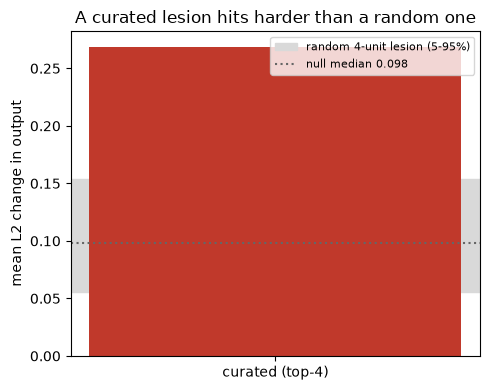

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(5, 4))
ax.axhspan(lo, hi, color='0.85', label='random 4-unit lesion (5-95%)')
ax.axhline(med, ls=':', c='0.4', label=f'null median {med:.3f}')
ax.bar(['curated (top-4)'], [curated_effect], width=0.4, color='#c0392b')
ax.set_ylabel('mean L2 change in output'); ax.set_ylim(0)
ax.set_title('A curated lesion hits harder than a random one'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## Restore exactly

`reset()` undoes every active perturbation. Here the restored output equals the baseline bit-for-bit.

In [5]:
bs.reset()
restored = net(x).detach().numpy()
print('restored equals baseline exactly:', np.array_equal(restored, baseline))

restored equals baseline exactly: True


**Reading it:** the grey band is the effect of lesioning 4 *random* units. The
curated top-4 sits above it, so those units carry more of the output than chance —
the lesion is targeting real structure, not just removing any 4 units. `reset()`
then returns the network to its exact prior state.